In [6]:
import numpy as np
import pandas as pd

In [7]:
match=pd.read_csv('/content/matches.csv')

In [8]:
match.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [9]:
match.shape

(756, 18)

In [10]:
deliveries=pd.read_csv('/content/deliveries.csv.zip')

In [11]:
deliveries.shape

(179078, 21)

In [12]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


#we need to find out total runs scored in each match

In [13]:
total_score_df=deliveries.groupby(['match_id','inning']).sum()['total_runs'].reset_index()

In [14]:
total_score_df

,match_id,inning,total_runs
0,1,1,207
1,1,2,172
2,2,1,184
3,2,2,187
4,3,1,183
...,...,...,...
1523,11413,2,170
1524,11414,1,155
1525,11414,2,162
1526,11415,1,152


we need to keep only first innings total to determine precentage chances of win at 2 inningd'

In [15]:
total_score_df=total_score_df[total_score_df['inning']==1]

In [16]:
total_score_df

,match_id,inning,total_runs
0,1,1,207
2,2,1,184
4,3,1,183
6,4,1,163
8,5,1,157
...,...,...,...
1518,11347,1,143
1520,11412,1,136
1522,11413,1,171
1524,11414,1,155


mrege with the matches detail to combine the first innings score with matches

In [17]:
match_df=match.merge(total_score_df[['match_id','total_runs']],left_on='id',right_on='match_id')

In [18]:
match_df

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1,207
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2,184
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,3,183
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,4,163
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,5,157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,11347,IPL-2019,Mumbai,05-05-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi,11347,143
752,11412,IPL-2019,Chennai,07-05-2019,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould,11412,136
753,11413,IPL-2019,Visakhapatnam,08-05-2019,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN,11413,171
754,11414,IPL-2019,Visakhapatnam,10-05-2019,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin,11414,155


In [19]:
match_df['team1'].unique()

array(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants',
       'Delhi Capitals'], dtype=object)

removing the non playing teams and replacing the common team names to same name
like dd-dc
same

In [20]:
teams=[
    'Sunrisers Hyderabad',
    'Mumbai Indians',
    'Royal Challengers Bangalore',
    'Kolkata Knight Riders',
    'Kings XI Punjab',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Delhi Capitals'
]

In [21]:
match_df['team1'] = match_df['team1'].str.replace('Delhi Daredevils', 'Delhi Capitals')
match_df['team2'] = match_df['team2'].str.replace('Delhi Daredevils', 'Delhi Capitals')
match_df['team1'] = match_df['team1'].str.replace('Deccan Chargers', 'Sunrisers Hyderabad')
match_df['team2'] = match_df['team2'].str.replace('Deccan Chargers', 'Sunrisers Hyderabad')
match_df['winner']=match_df['winner'].str.replace('Delhi Daredevils','Delhi Capitals')
match_df['winner']=match_df['winner'].str.replace('Deccan Chargers','Sunrisers Hyderabad')

In [22]:
match_df = match_df[match_df['team1'].isin(teams)]
match_df = match_df[match_df['team2'].isin(teams)]

In [23]:
match_df.columns

Index(['id', 'Season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3', 'match_id', 'total_runs'],
      dtype='object')

In [24]:
match_df['team2'].unique()

array(['Royal Challengers Bangalore', 'Delhi Capitals', 'Mumbai Indians',
       'Kings XI Punjab', 'Kolkata Knight Riders', 'Sunrisers Hyderabad',
       'Rajasthan Royals', 'Chennai Super Kings'], dtype=object)

In [25]:
match_df.shape

(641, 20)

remove rain affected matches


In [26]:
match_df=match_df[match_df['dl_applied']==0]

In [27]:
match_df.shape

(626, 20)

# to understand which columns are required

In [28]:
match_df=match_df[['match_id','city','total_runs','winner']]

In [29]:
match_df['winner'].unique()

array(['Sunrisers Hyderabad', 'Royal Challengers Bangalore',
       'Mumbai Indians', 'Kings XI Punjab', 'Kolkata Knight Riders',
       'Delhi Capitals', 'Chennai Super Kings', 'Rajasthan Royals', nan],
      dtype=object)

In [30]:
match_df

,match_id,city,total_runs,winner
0,1,Hyderabad,207,Sunrisers Hyderabad
4,5,Bangalore,157,Royal Challengers Bangalore
6,7,Mumbai,178,Mumbai Indians
7,8,Indore,148,Kings XI Punjab
9,10,Mumbai,158,Mumbai Indians
...,...,...,...,...
751,11347,Mumbai,143,Mumbai Indians
752,11412,Chennai,136,Mumbai Indians
753,11413,Visakhapatnam,171,Delhi Capitals
754,11414,Visakhapatnam,155,Chennai Super Kings


In [31]:
delivery_df=match_df.merge(deliveries,on='match_id')

In [32]:
delivery_df=delivery_df[delivery_df['inning']==2]

In [33]:
delivery_df

,match_id,city,total_runs_x,winner,inning,batting_team,bowling_team,over,ball,batsman,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder
125,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,0,0,0,0,1,0,1,NaN,NaN,NaN
126,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,0,0,0,0,0,0,NaN,NaN,NaN
127,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,0,0,0,0,0,0,NaN,NaN,NaN
128,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,0,0,0,0,2,0,2,NaN,NaN,NaN
129,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,0,0,0,0,4,0,4,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149573,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,0,0,0,0,1,0,1,NaN,NaN,NaN
149574,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,0,0,0,0,2,0,2,NaN,NaN,NaN
149575,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
149576,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,0,0,0,0,2,0,2,NaN,NaN,NaN


#after each ball we have to caculate runsleft
cumsum works on only numeric datatypes and it gives running sum

In [34]:
delivery_df['total_runs_y'] = pd.to_numeric(delivery_df['total_runs_y'], errors='coerce')
delivery_df['current_score'] = delivery_df.groupby('match_id')['total_runs_y'].cumsum()

In [35]:
delivery_df['runs_left']=(delivery_df['total_runs_x']+1)-delivery_df['current_score']

In [36]:
delivery_df

,match_id,city,total_runs_x,winner,inning,batting_team,bowling_team,over,ball,batsman,...,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,runs_left
125,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,0,0,1,0,1,NaN,NaN,NaN,1,207
126,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,0,0,0,0,NaN,NaN,NaN,1,207
127,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,0,0,0,0,NaN,NaN,NaN,1,207
128,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,0,0,2,0,2,NaN,NaN,NaN,3,205
129,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,0,0,4,0,4,NaN,NaN,NaN,7,201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149573,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,0,0,1,0,1,NaN,NaN,NaN,152,1
149574,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,0,0,2,0,2,NaN,NaN,NaN,154,-1
149575,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,0,0,1,0,1,SR Watson,run out,KH Pandya,155,-2
149576,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,0,0,2,0,2,NaN,NaN,NaN,157,-4


over = 1, ball = 1
→ (1-1)*6 + 1 = 1 ✅

In [37]:
delivery_df['BallsLeft']=120 - ((delivery_df['over'] - 1)*6 + delivery_df['ball'])

In [38]:
delivery_df

,match_id,city,total_runs_x,winner,inning,batting_team,bowling_team,over,ball,batsman,...,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,runs_left,BallsLeft
125,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,0,1,0,1,NaN,NaN,NaN,1,207,119
126,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,0,0,0,NaN,NaN,NaN,1,207,118
127,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,0,0,0,NaN,NaN,NaN,1,207,117
128,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,0,2,0,2,NaN,NaN,NaN,3,205,116
129,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,0,4,0,4,NaN,NaN,NaN,7,201,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149573,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,0,1,0,1,NaN,NaN,NaN,152,1,4
149574,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,0,2,0,2,NaN,NaN,NaN,154,-1,3
149575,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,0,1,0,1,SR Watson,run out,KH Pandya,155,-2,2
149576,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,0,2,0,2,NaN,NaN,NaN,157,-4,1


#wickets left is somewhat tricky
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].fillna("0")
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].apply(lambda x:x if x == "0" else "1")
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].astype('int')
wickets = delivery_df.groupby('match_id')['player_dismissed'].cumsum().values
delivery_df['wickets'] = 10 - wickets
delivery_df.drop(columns=['wickets_left'], inplace=True)
delivery_df.head()

In [39]:
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].fillna("0")
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].apply(lambda x:x if x == "0" else "1")
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].astype(int)
wickets=delivery_df.groupby('match_id')['player_dismissed'].cumsum().values
print(wickets)
delivery_df['wickets_left']=10-wickets

[0 0 0 ... 6 6 7]


In [40]:
#crr=current_runs/oversleft

current score/(120-deliveryleft/6)->overs left


Example: If a team scores 150 runs in 25.3 overs (which is
 CRR is
150/25.5=5.88 per over

 runs per over.

 overs), the CRR is



 runs per over.

In [41]:
delivery_df['crr']=(delivery_df['current_score']*6)/(120-delivery_df['BallsLeft'])


In [42]:
### rrr=runsleft/overs.left

In [43]:
delivery_df['rrr']=((delivery_df['runs_left']*6)/delivery_df['BallsLeft'])

In [44]:
delivery_df

,match_id,city,total_runs_x,winner,inning,batting_team,bowling_team,over,ball,batsman,...,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,runs_left,BallsLeft,wickets_left,crr,rrr
125,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,1,0,NaN,NaN,1,207,119,10,6.000000,10.436975
126,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,0,NaN,NaN,1,207,118,10,3.000000,10.525424
127,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,0,NaN,NaN,1,207,117,10,2.000000,10.615385
128,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,2,0,NaN,NaN,3,205,116,10,4.500000,10.603448
129,1,Hyderabad,207,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,4,0,NaN,NaN,7,201,115,10,8.400000,10.486957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149573,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,1,0,NaN,NaN,152,1,4,5,7.862069,1.500000
149574,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,2,0,NaN,NaN,154,-1,3,5,7.897436,-2.000000
149575,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,1,1,run out,KH Pandya,155,-2,2,4,7.881356,-6.000000
149576,11415,Hyderabad,152,Mumbai Indians,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,2,0,NaN,NaN,157,-4,1,4,7.915966,-24.000000


In [45]:
def result(row):
  return 1 if row['batting_team']==row['winner'] else 0


delivery_df['result']=delivery_df.apply(result,axis=1)

In [46]:
delivery_df = delivery_df[(delivery_df['BallsLeft'] > 0)&(delivery_df['runs_left']>0)]

In [47]:
final_df=delivery_df[['city','batting_team','bowling_team','wickets_left','total_runs_x','runs_left','BallsLeft','crr','rrr','result']]

we will shuffle the dataset as 1match all balls are together so some biasing may develop


👉 “Take all rows (final_df.shape[0]) and rearrange them randomly”

In [48]:
final_df

,city,batting_team,bowling_team,wickets_left,total_runs_x,runs_left,BallsLeft,crr,rrr,result
125,Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,10,207,207,119,6.000000,10.436975,0
126,Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,10,207,207,118,3.000000,10.525424,0
127,Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,10,207,207,117,2.000000,10.615385,0
128,Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,10,207,205,116,4.500000,10.603448,0
129,Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,10,207,201,115,8.400000,10.486957,0
...,...,...,...,...,...,...,...,...,...,...
149569,Hyderabad,Chennai Super Kings,Mumbai Indians,5,152,13,8,7.500000,9.750000,0
149570,Hyderabad,Chennai Super Kings,Mumbai Indians,5,152,11,7,7.539823,9.428571,0
149571,Hyderabad,Chennai Super Kings,Mumbai Indians,5,152,3,6,7.894737,3.000000,0
149572,Hyderabad,Chennai Super Kings,Mumbai Indians,5,152,2,5,7.878261,2.400000,0


In [49]:
final_df=final_df.sample(final_df.shape[0])

In [50]:
final_df

,city,batting_team,bowling_team,wickets_left,total_runs_x,runs_left,BallsLeft,crr,rrr,result
116651,Hyderabad,Sunrisers Hyderabad,Kings XI Punjab,5,143,5,16,8.019231,1.875000,1
35032,Bangalore,Royal Challengers Bangalore,Kings XI Punjab,8,203,49,28,10.108696,10.500000,1
75835,Bangalore,Royal Challengers Bangalore,Delhi Daredevils,10,152,149,108,2.000000,8.277778,1
130401,Jaipur,Kings XI Punjab,Rajasthan Royals,8,161,117,67,5.094340,10.477612,0
92007,Delhi,Rajasthan Royals,Delhi Daredevils,8,152,39,32,7.772727,7.312500,1
...,...,...,...,...,...,...,...,...,...,...
103563,Visakhapatnam,Rajasthan Royals,Sunrisers Hyderabad,10,127,127,118,3.000000,6.457627,1
127971,Bengaluru,Kolkata Knight Riders,Royal Challengers Bangalore,9,185,108,65,8.509091,9.969231,1
132929,Bengaluru,Sunrisers Hyderabad,Royal Challengers Bangalore,10,222,195,103,9.882353,11.359223,0
69784,Mumbai,Mumbai Indians,Kolkata Knight Riders,9,140,103,74,4.956522,8.351351,0


In [51]:
final_df.dropna(inplace=True)
final_df=final_df[final_df['BallsLeft']!=0]#to drop infinte values of runrate

In [52]:
X=final_df.iloc[:,:-1]
y=final_df.iloc[:,-1]

Example (visual)

Suppose columns:

[ A , B , C , D ]
  0   1   2   3


Now:

:-1

 means:

[ A , B , C ]

(D is excluded)

Why exclude last column?

Because usually:

last column = target (y)
rest = features (X)

🔄 Now understand -1 alone
final_df.iloc[:, -1]

 means:

last column only

Example:

D
 So your correct split:
X = final_df.iloc[:, :-1]   # all except last
y = final_df.iloc[:, -1]    # only last
 Quick mental shortcut
:-1 → drop last
-1 → only last

print(final_df.columns)
print(final_df.iloc[:, :-1].columns)
print(final_df.iloc[:, -1].head())






In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
trf=ColumnTransformer(
      [('trf',OneHotEncoder(sparse_output=False,drop='first'),['batting_team','bowling_team','city'])],
  remainder='passthrough')

🔍 Break it step by step
1. 🔄 OneHotEncoder(...)

This converts categories → numbers.

Example:
batting_team:
MI, CSK, RCB

Becomes:

MI  → [1,0,0]
CSK → [0,1,0]
RCB → [0,0,1]
2. ⚠️ drop='first'

This is important.

Instead of:

[1,0,0], [0,1,0], [0,0,1]

It becomes:

[0,0], [1,0], [0,1]

👉 Why?

To avoid duplicate information (multicollinearity)
(Simple: we remove one column because it's predictable from others)

3. 📦 sparse_output=False

By default:

output = compressed matrix (hard to read)

With this:
👉 output = normal numpy array (easy to use)

4. 🧩 ColumnTransformer

This is the main thing.

👉 It says:

“Apply encoding only to specific columns, not whole dataset”

Inside it:
[('trf', OneHotEncoder(...), ['batting_team','bowling_team','city'])]

This means:

'trf' → just a name (you can call it anything)
OneHotEncoder(...) → what to apply
['batting_team', ...] → where to apply
5. 🔁 remainder='passthrough'

This is VERY important.

👉 It says:

“Keep all other columns as they are”

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [56]:
X_train

,city,batting_team,bowling_team,wickets_left,total_runs_x,runs_left,BallsLeft,crr,rrr
1601,Bangalore,Mumbai Indians,Royal Challengers Bangalore,6,142,112,78,4.428571,8.615385
54530,Bangalore,Kings XI Punjab,Royal Challengers Bangalore,3,205,115,29,6.000000,23.793103
15428,Kolkata,Delhi Daredevils,Kolkata Knight Riders,6,133,97,85,6.342857,6.847059
116899,Chandigarh,Kings XI Punjab,Mumbai Indians,3,189,35,4,8.017241,52.500000
124988,Mohali,Sunrisers Hyderabad,Kings XI Punjab,9,201,199,114,3.000000,10.473684
...,...,...,...,...,...,...,...,...,...
44195,Jaipur,Rajasthan Royals,Mumbai Indians,6,174,128,72,5.875000,10.666667
1823,Kolkata,Sunrisers Hyderabad,Kolkata Knight Riders,10,172,154,101,6.000000,9.148515
135695,Kolkata,Kolkata Knight Riders,Sunrisers Hyderabad,6,189,40,13,8.411215,18.461538
53327,Chennai,Deccan Chargers,Chennai Super Kings,6,165,29,12,7.611111,14.500000


In [57]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=5)

In [58]:
#for strong last probability prediction predict use random forest else for each step prediction use logistic regression

In [59]:
pipe=Pipeline(steps=[
    ('step1',trf),
    ('step2',StandardScaler()),
    ('step3',LogisticRegression(solver='liblinear'))
])

In [60]:
pipe.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'city'])])),
                ('step2', StandardScaler()),
                ('step3', LogisticRegression(solver='liblinear'))])

In [61]:
y_pred=pipe.predict(X_test)

In [62]:
from sklearn.metrics import accuracy_score

In [63]:
accuracy_score(y_test,y_pred)

0.8407953183388563

logistic regression would give better probability distribution results

In [64]:
from sklearn.metrics import confusion_matrix,classification_report

In [65]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      7783
           1       0.81      0.85      0.83      6400

    accuracy                           0.84     14183
   macro avg       0.84      0.84      0.84     14183
weighted avg       0.84      0.84      0.84     14183



In [66]:
delivery_df.columns

Index(['match_id', 'city', 'total_runs_x', 'winner', 'inning', 'batting_team',
       'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler',
       'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs',
       'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs_y',
       'player_dismissed', 'dismissal_kind', 'fielder', 'current_score',
       'runs_left', 'BallsLeft', 'wickets_left', 'crr', 'rrr', 'result'],
      dtype='object')

In [67]:
def match_progression(x_df, match_id, pipe):

    # ensure correct type
    x_df = x_df.copy()
    x_df['match_id'] = x_df['match_id'].astype(str)

    # filter match + end of over
    match_df = x_df[
        (x_df['match_id'] == str(match_id)) &
        (x_df['ball'] == 6)
    ]

    cols = ['city','batting_team','bowling_team','runs_left',
            'BallsLeft','wickets_left','crr','rrr','total_runs_x']

    temp = match_df[cols].dropna().copy()

    # remove last ball case
    temp = temp[temp['BallsLeft'] != 0]

    # safety check
    if temp.empty:
        print("No data found for this match")
        return None, None

    # sort properly (important)
    temp = temp.sort_values('BallsLeft', ascending=False)

    # target
    target = temp['total_runs_x'].iloc[0]

    # prediction
    probs = pipe.predict_proba(temp)
    temp['lose_prob'] = (probs[:, 0] * 100).round(2)
    temp['win_prob']  = (probs[:, 1] * 100).round(2)

    # over number
    temp['end_of_over'] = range(1, len(temp) + 1)

    # runs per over
    temp['runs_scored'] = temp['runs_left'].shift(1, fill_value=target) - temp['runs_left']

    # wickets per over
    temp['wickets_fall_per_over'] = temp['wickets_left'].shift(1, fill_value=10) - temp['wickets_left']

    # final output
    temp = temp[['end_of_over','runs_scored','wickets_fall_per_over','lose_prob','win_prob']]

    print("Target:", target)

    return target, temp

In [68]:
delivery_df['match_id'].unique()

array([    1,     5,     7,     8,    10,    11,    12,    14,    15,
          18,    19,    21,    22,    24,    27,    31,    32,    35,
          36,    37,    39,    42,    44,    45,    47,    48,    50,
          53,    55,    58,    60,    61,    62,    63,    64,    65,
          66,    67,    68,    69,    70,    71,    72,    73,    74,
          75,    76,    77,    78,    79,    80,    81,    82,    83,
          84,    85,    86,    87,    88,    89,    90,    91,    92,
          93,    94,    95,    96,    97,    98,    99,   101,   102,
         104,   105,   106,   107,   108,   109,   110,   111,   112,
         113,   114,   115,   116,   117,   118,   119,   121,   122,
         124,   125,   126,   127,   128,   129,   130,   131,   132,
         133,   134,   135,   136,   137,   138,   139,   140,   141,
         142,   143,   144,   145,   146,   147,   148,   150,   151,
         152,   153,   154,   155,   156,   157,   158,   159,   160,
         161,   162,

In [69]:
temp, target = match_progression(delivery_df,74,pipe)

Target: 178


Text(0.5, 1.0, 'Target-178')

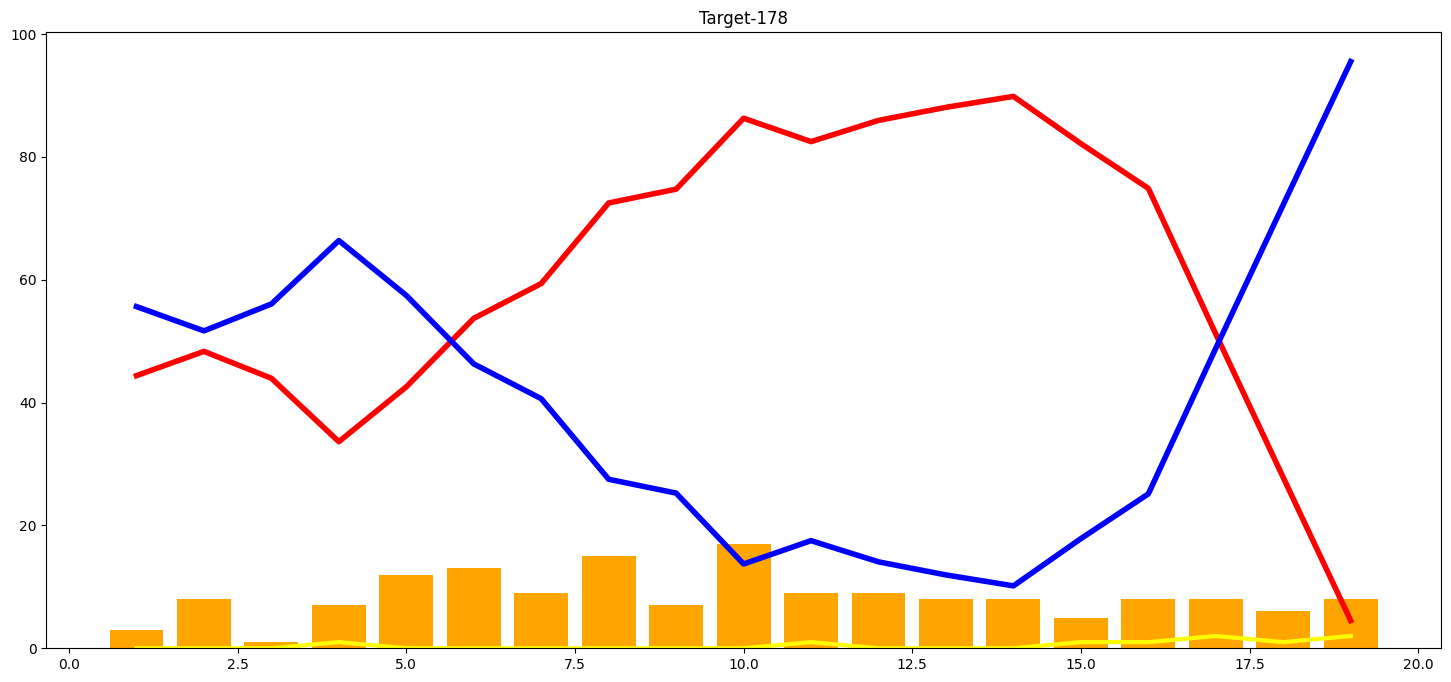

In [70]:
import matplotlib.pyplot as plt
plt.figure(figsize=(18,8))
plt.plot(target['end_of_over'],target['wickets_fall_per_over'],color='yellow',linewidth=3)
plt.plot(target['end_of_over'], target['win_prob'],color='red',linewidth=4)
plt.plot(target['end_of_over'], target['lose_prob'],color='blue',linewidth=4)
plt.bar(target['end_of_over'],target['runs_scored'],color='orange')
plt.title('Target-' + str(temp))

In [71]:
teams

['Sunrisers Hyderabad',
 'Mumbai Indians',
 'Royal Challengers Bangalore',
 'Kolkata Knight Riders',
 'Kings XI Punjab',
 'Chennai Super Kings',
 'Rajasthan Royals',
 'Delhi Capitals']

In [72]:
delivery_df['city'].unique()

array(['Hyderabad', 'Bangalore', 'Mumbai', 'Indore', 'Kolkata', 'Delhi',
       'Chandigarh', 'Jaipur', 'Chennai', 'Cape Town', 'Port Elizabeth',
       'Durban', 'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi', 'Abu Dhabi',
       'Sharjah', nan, 'Mohali', 'Bengaluru'], dtype=object)

In [74]:
import pickle
pickle.dump(pipe,open('pipe.pkl','wb'))